# 0825_kimjaehak_009_partial_rebalancing

검사유형별 XGBoost baseline에서 클래스 불균형 보정의 **강도**를 검증합니다.

기존 실험은 SMOTE, ADASYN, Random Undersampling을 주로 1:1 비율로 적용했습니다. 이 노트북은 완전 균형보다 약한 부분 리샘플링이 Validation PR-AUC와 미래 Test 성능 사이의 균형을 개선하는지 확인합니다.

실험 순서는 다음과 같습니다.

1. 고정 seed에서 리샘플링 기법 × 목표 비율을 Validation으로 선별합니다.
2. 검사유형별 상위 후보를 여러 리샘플링 seed로 반복해 안정성을 평가합니다.
3. `mean(PR-AUC) - std(PR-AUC)` 기준으로 설정을 고정합니다.
4. 고정된 설정과 seed로 Test를 한 번만 평가합니다.

모델 구조, 데이터 정리, 시간 분할, mapping 기반 피처는 `0824_kimjaehak_006_type_conditioned_baseline`과 동일하게 유지합니다. Test 결과를 본 뒤 후보, 비율, 선택 기준을 변경하지 않습니다.

## 1. 설정과 라이브러리

`SCREENING_RATIOS`는 리샘플링 후 `minority / majority` 비율입니다. 예를 들어 `0.10`은 약 1:10입니다. XGBoost seed는 고정하고 리샘러의 seed만 바꿔, 합성·추출 표본에 따른 변동을 분리해 측정합니다.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from imblearn.over_sampling import ADASYN, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from xgboost import XGBClassifier

EXPERIMENT_ID = "0825_kimjaehak_009_partial_rebalancing"
RANDOM_STATE = 42
FINAL_RESAMPLING_SEED = 42
STABILITY_SEEDS = [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
SCREENING_RATIOS = [0.05, 0.10, 0.25, 0.50, 1.00]
RESAMPLING_METHODS = ["smote", "adasyn", "undersample"]
TOP_K_PER_TYPE = 2
DECISION_THRESHOLD = 0.5

DATA_PATH = Path("../data/raw/dataset.csv")
MAPPING_PATH = Path("../data/raw/mapping.json")
TARGET = "class"
TIME_COLUMN = "timestamp"
TYPE_COLUMN = "inspection_type"
RECORD_ID = "record_id"

assert DATA_PATH.exists(), f"파일을 찾을 수 없습니다: {DATA_PATH.resolve()}"
assert MAPPING_PATH.exists(), f"파일을 찾을 수 없습니다: {MAPPING_PATH.resolve()}"
assert len(STABILITY_SEEDS) == len(set(STABILITY_SEEDS))
assert SCREENING_RATIOS == sorted(SCREENING_RATIOS)
assert all(0 < ratio <= 1 for ratio in SCREENING_RATIOS)

print("experiment:", EXPERIMENT_ID)
print("screening ratios:", SCREENING_RATIOS)
print("stability seeds:", STABILITY_SEEDS)

experiment: 0825_kimjaehak_009_partial_rebalancing
screening ratios: [0.05, 0.1, 0.25, 0.5, 1.0]
stability seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]


## 2. 전체 데이터 로딩과 baseline 기준 중복 제거

`record_id`와 `timestamp`를 중복 판단에서 제외합니다. 나머지 입력과 `class`가 모두 같으면 기존 baseline과 동일하게 첫 행만 남깁니다.

In [2]:
raw_df = pd.read_csv(DATA_PATH, low_memory=False)
source_index_column = raw_df.columns[0]

if source_index_column.startswith("Unnamed:"):
    raw_df = raw_df.rename(columns={source_index_column: RECORD_ID})
elif source_index_column != RECORD_ID:
    raise ValueError(f"예상하지 못한 첫 번째 컬럼: {source_index_column}")

required_columns = {RECORD_ID, TIME_COLUMN, TYPE_COLUMN, TARGET}
missing_required_columns = required_columns - set(raw_df.columns)
assert not missing_required_columns, f"필수 컬럼 누락: {missing_required_columns}"
assert raw_df[RECORD_ID].is_unique, "record_id가 고유하지 않습니다."

dedup_columns = [
    column
    for column in raw_df.columns
    if column not in {RECORD_ID, TIME_COLUMN}
]
duplicate_mask = raw_df.duplicated(subset=dedup_columns, keep="first")
clean_df = raw_df.loc[~duplicate_mask].copy().reset_index(drop=True)

assert not clean_df.duplicated(subset=dedup_columns, keep=False).any()
assert len(clean_df) + int(duplicate_mask.sum()) == len(raw_df)

pd.Series(
    {
        "rows_before": len(raw_df),
        "duplicate_rows_removed": int(duplicate_mask.sum()),
        "rows_after": len(clean_df),
        "positive_rate_before_pct": raw_df[TARGET].mean() * 100,
        "positive_rate_after_pct": clean_df[TARGET].mean() * 100,
    },
    name="data_preparation",
)

rows_before                 440274.000000
duplicate_rows_removed       48282.000000
rows_after                  391992.000000
positive_rate_before_pct         1.049801
positive_rate_after_pct          1.131656
Name: data_preparation, dtype: float64

## 3. timestamp-group 기준 60/20/20 시간순 분할

동일 timestamp의 행은 항상 같은 split에 둡니다. 리샘플링과 후보 선택은 Train·Validation만 사용하며 Test는 최종 설정이 고정된 뒤에만 엽니다.

In [3]:
clean_df[TIME_COLUMN] = pd.to_datetime(
    clean_df[TIME_COLUMN],
    errors="raise",
    utc=True,
)
clean_df = clean_df.sort_values(
    [TIME_COLUMN, RECORD_ID],
    kind="stable",
).reset_index(drop=True)

timestamp_group_sizes = clean_df[TIME_COLUMN].value_counts(sort=False).sort_index()
cumulative_rows = timestamp_group_sizes.cumsum().to_numpy()

train_end_position = int(
    np.searchsorted(cumulative_rows, len(clean_df) * 0.60, side="left")
)
valid_end_position = int(
    np.searchsorted(cumulative_rows, len(clean_df) * 0.80, side="left")
)
train_end_time = timestamp_group_sizes.index[train_end_position]
valid_end_time = timestamp_group_sizes.index[valid_end_position]

split_masks = {
    "train": clean_df[TIME_COLUMN] <= train_end_time,
    "validation": (
        (clean_df[TIME_COLUMN] > train_end_time)
        & (clean_df[TIME_COLUMN] <= valid_end_time)
    ),
    "test": clean_df[TIME_COLUMN] > valid_end_time,
}

split_summary = pd.DataFrame(
    [
        {
            "split": split_name,
            "rows": int(mask.sum()),
            "row_ratio_pct": mask.mean() * 100,
            "timestamp_groups": int(clean_df.loc[mask, TIME_COLUMN].nunique()),
            "positive_samples": (
                int(clean_df.loc[mask, TARGET].sum())
                if split_name != "test"
                else np.nan
            ),
            "positive_rate_pct": (
                clean_df.loc[mask, TARGET].mean() * 100
                if split_name != "test"
                else np.nan
            ),
            "start_time": clean_df.loc[mask, TIME_COLUMN].min(),
            "end_time": clean_df.loc[mask, TIME_COLUMN].max(),
        }
        for split_name, mask in split_masks.items()
    ]
).set_index("split")

assert split_summary["rows"].sum() == len(clean_df)
assert clean_df.loc[split_masks["train"], TIME_COLUMN].max() < clean_df.loc[
    split_masks["validation"], TIME_COLUMN
].min()
assert clean_df.loc[split_masks["validation"], TIME_COLUMN].max() < clean_df.loc[
    split_masks["test"], TIME_COLUMN
].min()

split_summary

,rows,row_ratio_pct,timestamp_groups,positive_samples,positive_rate_pct,start_time,end_time
split,,,,,,,
train,235222,60.006837,25501,1824.0,0.775438,1970-06-23 03:58:55+00:00,1970-09-28 05:48:26+00:00
validation,78374,19.993775,6282,363.0,0.463164,1970-09-28 05:49:10+00:00,1970-10-13 13:14:26+00:00
test,78396,19.999388,7165,NaN,NaN,1970-10-13 13:14:58+00:00,1970-11-02 14:21:28+00:00


## 4. 검사유형별 split과 mapping 기반 피처

공통 시간 경계를 적용한 뒤 `inspection_type`별 DataFrame을 구성합니다. 모델은 공통 `meta_feat`와 해당 유형에 mapping된 `inspection_feat`만 사용합니다.

In [4]:
inspection_types = sorted(clean_df[TYPE_COLUMN].unique().tolist())

with MAPPING_PATH.open(encoding="utf-8") as mapping_file:
    feature_mapping = json.load(mapping_file)

assert set(feature_mapping) == {str(value) for value in inspection_types}

meta_columns = [
    column for column in clean_df.columns if column.startswith("meta_feat")
]
feature_columns_by_type = {}
type_split_dfs = {}
type_split_summary_rows = []

for inspection_type in inspection_types:
    mapped_columns = feature_mapping[str(inspection_type)]
    assert len(mapped_columns) == len(set(mapped_columns))
    assert not (set(mapped_columns) - set(clean_df.columns))

    feature_columns_by_type[inspection_type] = meta_columns + mapped_columns
    type_split_dfs[inspection_type] = {}
    type_mask = clean_df[TYPE_COLUMN] == inspection_type

    for split_name, split_mask in split_masks.items():
        split_df = clean_df.loc[type_mask & split_mask].copy()
        type_split_dfs[inspection_type][split_name] = split_df
        type_split_summary_rows.append(
            {
                "inspection_type": inspection_type,
                "split": split_name,
                "rows": len(split_df),
                "positive_samples": (
                    int(split_df[TARGET].sum())
                    if split_name != "test"
                    else np.nan
                ),
                "positive_rate_pct": (
                    split_df[TARGET].mean() * 100
                    if split_name != "test"
                    else np.nan
                ),
                "features": len(feature_columns_by_type[inspection_type]),
            }
        )

type_split_summary = pd.DataFrame(type_split_summary_rows).set_index(
    ["inspection_type", "split"]
)

assert sum(
    len(frame)
    for split_frames in type_split_dfs.values()
    for frame in split_frames.values()
) == len(clean_df)

type_split_summary

rows  positive_samples  positive_rate_pct  \
inspection_type split                                                    
0               train       41961              57.0           0.135840   
                validation  23492               8.0           0.034054   
                test        16784               NaN                NaN   
1               train       34041             555.0           1.630387   
                validation  10494             239.0           2.277492   
                test        11112               NaN                NaN   
2               train       74910             579.0           0.772928   
                validation  15897              32.0           0.201296   
                test        19153               NaN                NaN   
3               train       80792             620.0           0.767403   
                validation  27328              24.0           0.087822   
                test        30591               NaN                NaN   
4               train        3518              13.0           0.369528   
                validation   1163              60.0           5.159071   
                test          756               NaN                NaN   

                            features  
inspection_type split                 
0               train             48  
                validation        48  
                test              48  
1               train             56  
                validation        56  
                test              56  
2               train             69  
                validation        69  
                test              69  
3               train             69  
                validation        69  
                test              69  
4               train             25  
                validation        25  
                test              25

## 5. 학습·리샘플링·평가 함수

- XGBoost 설정은 006과 동일합니다.
- `scale_pos_weight`는 적용하지 않습니다.
- Screening과 안정성 단계에서는 Test를 읽지 않습니다.
- 리샘플링 실패도 누락하지 않고 결과표에 기록합니다.

In [5]:
def build_model():
    return XGBClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
        objective="binary:logistic",
        eval_metric=["logloss", "aucpr"],
    )


def build_resampler(method, target_ratio, random_state):
    if method == "smote":
        return SMOTE(
            sampling_strategy=target_ratio,
            random_state=random_state,
            k_neighbors=5,
        )
    if method == "adasyn":
        return ADASYN(
            sampling_strategy=target_ratio,
            random_state=random_state,
            n_neighbors=5,
        )
    if method == "undersample":
        return RandomUnderSampler(
            sampling_strategy=target_ratio,
            random_state=random_state,
        )
    raise ValueError(f"지원하지 않는 리샘플링 방법: {method}")


def resample_training_data(X_train, y_train, method, target_ratio, seed):
    if method == "baseline":
        return X_train.copy(), y_train.copy()

    original_ratio = y_train.sum() / (len(y_train) - y_train.sum())
    if target_ratio <= original_ratio:
        raise ValueError(
            f"target_ratio={target_ratio:.4f}가 원본 minority/majority "
            f"비율={original_ratio:.4f} 이하입니다."
        )

    resampler = build_resampler(method, target_ratio, seed)
    X_resampled, y_resampled = resampler.fit_resample(X_train, y_train)
    return X_resampled, pd.Series(y_resampled, name=TARGET, dtype="int8")


def select_f1_threshold(y_true, probabilities):
    precision, recall, thresholds = precision_recall_curve(y_true, probabilities)
    if len(thresholds) == 0:
        return DECISION_THRESHOLD
    f1_values = 2 * precision[:-1] * recall[:-1] / (
        precision[:-1] + recall[:-1] + 1e-12
    )
    return float(thresholds[int(np.nanargmax(f1_values))])


def evaluate_probabilities(y_true, probabilities, threshold):
    y_true = np.asarray(y_true, dtype="int8")
    probabilities = np.asarray(probabilities, dtype="float64")
    predictions = (probabilities >= threshold).astype("int8")
    tn, fp, fn, tp = confusion_matrix(
        y_true, predictions, labels=[0, 1]
    ).ravel()
    return {
        "threshold": float(threshold),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "specificity": tn / (tn + fp),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
    }


def fit_and_score_validation(
    inspection_type,
    method,
    target_ratio,
    resampling_seed,
):
    feature_columns = feature_columns_by_type[inspection_type]
    train_df = type_split_dfs[inspection_type]["train"]
    valid_df = type_split_dfs[inspection_type]["validation"]

    X_train = train_df[feature_columns]
    y_train = train_df[TARGET].astype("int8")
    X_valid = valid_df[feature_columns]
    y_valid = valid_df[TARGET].astype("int8")

    X_fit, y_fit = resample_training_data(
        X_train,
        y_train,
        method,
        target_ratio,
        resampling_seed,
    )
    model = build_model()
    model.fit(X_fit, y_fit, verbose=False)
    valid_probabilities = model.predict_proba(X_valid)[:, 1]
    selected_threshold = select_f1_threshold(y_valid, valid_probabilities)

    fixed_metrics = evaluate_probabilities(
        y_valid, valid_probabilities, DECISION_THRESHOLD
    )
    tuned_metrics = evaluate_probabilities(
        y_valid, valid_probabilities, selected_threshold
    )
    return {
        "model": model,
        "validation_probabilities": valid_probabilities,
        "train_rows_original": len(y_train),
        "train_positive_original": int(y_train.sum()),
        "train_rows_resampled": len(y_fit),
        "train_positive_resampled": int(np.asarray(y_fit).sum()),
        "resampled_ratio": (
            np.asarray(y_fit).sum()
            / (len(y_fit) - np.asarray(y_fit).sum())
        ),
        "fixed_metrics": fixed_metrics,
        "tuned_metrics": tuned_metrics,
    }

## 6. 1단계: 부분 리샘플링 비율 Screening

고정 seed `42`에서 baseline과 `3개 기법 × 5개 비율`을 비교합니다. 후보 순위는 Validation PR-AUC만 사용합니다. Test는 이 단계에서 접근하지 않습니다.

In [6]:
screening_rows = []

for inspection_type in inspection_types:
    configurations = [("baseline", np.nan)] + [
        (method, ratio)
        for method in RESAMPLING_METHODS
        for ratio in SCREENING_RATIOS
    ]

    for method, target_ratio in configurations:
        try:
            result = fit_and_score_validation(
                inspection_type=inspection_type,
                method=method,
                target_ratio=target_ratio,
                resampling_seed=RANDOM_STATE,
            )
            row = {
                "inspection_type": inspection_type,
                "method": method,
                "target_ratio": target_ratio,
                "status": "ok",
                "error": "",
                "train_rows_original": result["train_rows_original"],
                "train_positive_original": result["train_positive_original"],
                "train_rows_resampled": result["train_rows_resampled"],
                "train_positive_resampled": result["train_positive_resampled"],
                "resampled_ratio": result["resampled_ratio"],
                "validation_pr_auc": result["fixed_metrics"]["pr_auc"],
                "validation_roc_auc": result["fixed_metrics"]["roc_auc"],
                "fixed_0_5_f1": result["fixed_metrics"]["f1"],
                "fixed_0_5_recall": result["fixed_metrics"]["recall"],
                "selected_f1_threshold": result["tuned_metrics"]["threshold"],
                "selected_threshold_f1": result["tuned_metrics"]["f1"],
                "selected_threshold_recall": result["tuned_metrics"]["recall"],
            }
        except ValueError as error:
            row = {
                "inspection_type": inspection_type,
                "method": method,
                "target_ratio": target_ratio,
                "status": "failed",
                "error": str(error),
            }
        screening_rows.append(row)

screening_df = pd.DataFrame(screening_rows).sort_values(
    ["inspection_type", "validation_pr_auc"],
    ascending=[True, False],
    na_position="last",
).reset_index(drop=True)

screening_df

,inspection_type,method,target_ratio,status,error,train_rows_original,train_positive_original,train_rows_resampled,train_positive_resampled,resampled_ratio,validation_pr_auc,validation_roc_auc,fixed_0_5_f1,fixed_0_5_recall,selected_f1_threshold,selected_threshold_f1,selected_threshold_recall
0,0,undersample,0.50,ok,,41961,57,171,57,0.500000,0.004121,0.919057,0.004044,0.750000,0.978865,0.017621,0.250000
1,0,undersample,1.00,ok,,41961,57,114,57,1.000000,0.002702,0.858036,0.001964,0.875000,0.986706,0.012384,0.250000
2,0,undersample,0.05,ok,,41961,57,1197,57,0.050000,0.002480,0.899277,0.000000,0.000000,0.052616,0.008048,0.250000
3,0,baseline,NaN,ok,,41961,57,41961,57,0.001360,0.002405,0.807230,0.000000,0.000000,0.005011,0.017094,0.125000
4,0,undersample,0.25,ok,,41961,57,285,57,0.250000,0.002063,0.857943,0.003995,0.375000,0.817052,0.007905,0.250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,4,adasyn,0.10,ok,,3518,13,3861,356,0.101569,0.054913,0.377229,0.015748,0.016667,0.000026,0.100418,1.000000
76,4,baseline,NaN,ok,,3518,13,3518,13,0.003709,0.054825,0.380168,0.032787,0.016667,0.000003,0.100255,0.983333
77,4,adasyn,0.50,ok,,3518,13,5252,1747,0.498431,0.054393,0.370663,0.009091,0.016667,0.000036,0.099656,0.966667
78,4,adasyn,1.00,ok,,3518,13,7009,3504,0.999715,0.053568,0.359066,0.008658,0.016667,0.000014,0.098280,1.000000


,inspection_type,method,target_ratio,validation_pr_auc
0,0,undersample,0.50,0.004121
1,0,undersample,1.00,0.002702
2,1,adasyn,0.50,0.615456
3,1,undersample,0.10,0.612806
4,2,undersample,0.50,0.334686
5,2,undersample,0.25,0.313442
6,3,undersample,0.05,0.281812
7,3,undersample,0.10,0.198004
8,4,undersample,1.00,0.113376
9,4,undersample,0.10,0.074271


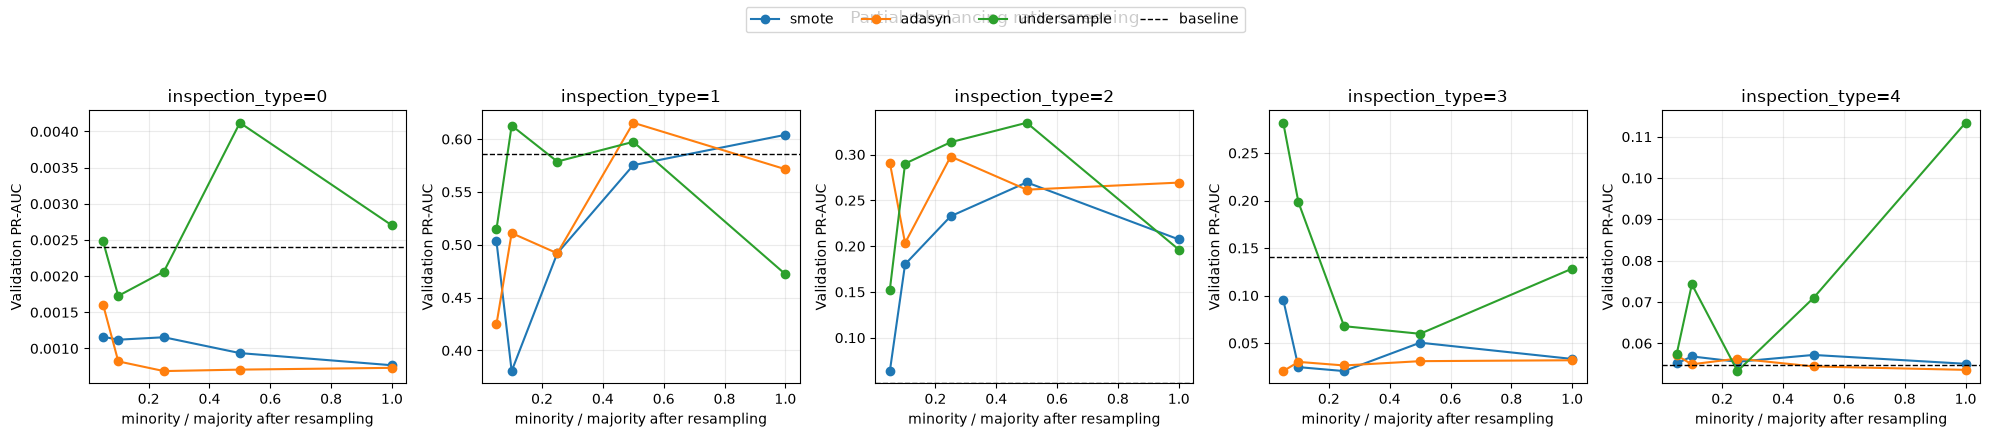

In [7]:
successful_nonbaseline = screening_df.loc[
    (screening_df["status"] == "ok")
    & (screening_df["method"] != "baseline")
].copy()

top_screening_candidates = (
    successful_nonbaseline
    .sort_values(
        ["inspection_type", "validation_pr_auc"],
        ascending=[True, False],
    )
    .groupby("inspection_type", as_index=False, group_keys=False)
    .head(TOP_K_PER_TYPE)
    [["inspection_type", "method", "target_ratio", "validation_pr_auc"]]
    .reset_index(drop=True)
)

baseline_validation = (
    screening_df.loc[screening_df["method"] == "baseline"]
    .set_index("inspection_type")["validation_pr_auc"]
)

display(top_screening_candidates)

fig, axes = plt.subplots(1, len(inspection_types), figsize=(20, 4), sharey=False)
for ax, inspection_type in zip(axes, inspection_types):
    plot_df = successful_nonbaseline.loc[
        successful_nonbaseline["inspection_type"] == inspection_type
    ]
    for method in RESAMPLING_METHODS:
        method_df = plot_df.loc[plot_df["method"] == method].sort_values(
            "target_ratio"
        )
        ax.plot(
            method_df["target_ratio"],
            method_df["validation_pr_auc"],
            marker="o",
            label=method,
        )
    ax.axhline(
        baseline_validation.loc[inspection_type],
        color="black",
        linestyle="--",
        linewidth=1,
        label="baseline",
    )
    ax.set_title(f"inspection_type={inspection_type}")
    ax.set_xlabel("minority / majority after resampling")
    ax.set_ylabel("Validation PR-AUC")
    ax.grid(alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4)
fig.suptitle("Partial rebalancing ratio screening", y=1.08)
plt.tight_layout()
plt.show()

## 7. 2단계: 상위 후보의 seed 안정성 검증

각 유형의 Screening 상위 후보 2개를 10개 리샘플링 seed로 반복합니다. XGBoost seed는 계속 `42`로 고정합니다. 후보는 Validation PR-AUC의 `평균 - 표준편차`가 가장 큰 설정으로 선택합니다.

이 점수는 평균 성능이 높더라도 seed에 따라 크게 흔들리는 설정을 불리하게 평가하기 위한 단순하고 사전 고정된 보수적 기준입니다.

In [8]:
stability_rows = []

for candidate in top_screening_candidates.itertuples(index=False):
    for seed in STABILITY_SEEDS:
        try:
            result = fit_and_score_validation(
                inspection_type=candidate.inspection_type,
                method=candidate.method,
                target_ratio=candidate.target_ratio,
                resampling_seed=seed,
            )
            stability_rows.append(
                {
                    "inspection_type": candidate.inspection_type,
                    "method": candidate.method,
                    "target_ratio": candidate.target_ratio,
                    "seed": seed,
                    "status": "ok",
                    "error": "",
                    "validation_pr_auc": result["fixed_metrics"]["pr_auc"],
                    "validation_roc_auc": result["fixed_metrics"]["roc_auc"],
                    "selected_f1_threshold": result["tuned_metrics"]["threshold"],
                    "selected_threshold_f1": result["tuned_metrics"]["f1"],
                    "selected_threshold_recall": result["tuned_metrics"]["recall"],
                }
            )
        except ValueError as error:
            stability_rows.append(
                {
                    "inspection_type": candidate.inspection_type,
                    "method": candidate.method,
                    "target_ratio": candidate.target_ratio,
                    "seed": seed,
                    "status": "failed",
                    "error": str(error),
                }
            )

stability_df = pd.DataFrame(stability_rows)
stability_df

,inspection_type,method,target_ratio,seed,status,error,validation_pr_auc,validation_roc_auc,selected_f1_threshold,selected_threshold_f1,selected_threshold_recall
0,0,undersample,0.5,42,ok,,0.004121,0.919057,0.978865,0.017621,0.250000
1,0,undersample,0.5,43,ok,,0.003439,0.860192,0.930879,0.016949,0.375000
2,0,undersample,0.5,44,ok,,0.000734,0.744555,0.386338,0.001801,0.625000
3,0,undersample,0.5,45,ok,,0.002703,0.803925,0.930684,0.011887,0.500000
4,0,undersample,0.5,46,ok,,0.005985,0.857451,0.888345,0.027875,0.500000
...,...,...,...,...,...,...,...,...,...,...,...
95,4,undersample,0.1,47,ok,,0.043140,0.446487,0.002924,0.103627,0.666667
96,4,undersample,0.1,48,ok,,0.047135,0.443608,0.003618,0.104218,0.700000
97,4,undersample,0.1,49,ok,,0.054093,0.364695,0.000607,0.100083,1.000000
98,4,undersample,0.1,50,ok,,0.077993,0.467641,0.174799,0.168067,0.166667


In [9]:
stability_summary_rows = []

for keys, group in stability_df.loc[
    stability_df["status"] == "ok"
].groupby(["inspection_type", "method", "target_ratio"]):
    inspection_type, method, target_ratio = keys
    baseline_score = baseline_validation.loc[inspection_type]
    pr_auc_values = group["validation_pr_auc"]
    pr_auc_std = pr_auc_values.std(ddof=1)
    stability_summary_rows.append(
        {
            "inspection_type": inspection_type,
            "method": method,
            "target_ratio": target_ratio,
            "successful_seeds": len(group),
            "validation_pr_auc_mean": pr_auc_values.mean(),
            "validation_pr_auc_std": pr_auc_std,
            "validation_pr_auc_min": pr_auc_values.min(),
            "validation_pr_auc_max": pr_auc_values.max(),
            "win_rate_vs_baseline": (pr_auc_values > baseline_score).mean(),
            "robust_score": pr_auc_values.mean() - pr_auc_std,
        }
    )

stability_summary = pd.DataFrame(stability_summary_rows)

baseline_selection_rows = pd.DataFrame(
    [
        {
            "inspection_type": inspection_type,
            "method": "baseline",
            "target_ratio": np.nan,
            "successful_seeds": 1,
            "validation_pr_auc_mean": baseline_validation.loc[inspection_type],
            "validation_pr_auc_std": 0.0,
            "validation_pr_auc_min": baseline_validation.loc[inspection_type],
            "validation_pr_auc_max": baseline_validation.loc[inspection_type],
            "win_rate_vs_baseline": 0.0,
            "robust_score": baseline_validation.loc[inspection_type],
        }
        for inspection_type in inspection_types
    ]
)

selection_pool = pd.concat(
    [baseline_selection_rows, stability_summary],
    ignore_index=True,
)
selected_configurations = (
    selection_pool
    .sort_values(
        ["inspection_type", "robust_score", "validation_pr_auc_mean"],
        ascending=[True, False, False],
    )
    .groupby("inspection_type", as_index=False, group_keys=False)
    .head(1)
    .reset_index(drop=True)
)

display(stability_summary.sort_values(["inspection_type", "robust_score"], ascending=[True, False]))
display(selected_configurations)

,inspection_type,method,target_ratio,successful_seeds,validation_pr_auc_mean,validation_pr_auc_std,validation_pr_auc_min,validation_pr_auc_max,win_rate_vs_baseline,robust_score
0,0,undersample,0.50,10,0.003074,0.001792,0.000734,0.005985,0.7,0.001282
1,0,undersample,1.00,10,0.002856,0.001579,0.000981,0.006572,0.7,0.001276
2,1,adasyn,0.50,10,0.576088,0.036756,0.530416,0.655380,0.3,0.539332
3,1,undersample,0.10,10,0.507477,0.059614,0.428785,0.612806,0.1,0.447863
4,2,undersample,0.25,10,0.215149,0.110551,0.040080,0.372506,0.9,0.104598
5,2,undersample,0.50,10,0.198731,0.102315,0.071010,0.334686,1.0,0.096416
7,3,undersample,0.10,10,0.125587,0.057688,0.040611,0.204696,0.4,0.067898
6,3,undersample,0.05,10,0.111489,0.076556,0.030226,0.281812,0.3,0.034933
9,4,undersample,1.00,10,0.075772,0.026678,0.037150,0.113376,0.7,0.049094
8,4,undersample,0.10,10,0.072144,0.033529,0.043140,0.155786,0.6,0.038615


,inspection_type,method,target_ratio,successful_seeds,validation_pr_auc_mean,validation_pr_auc_std,validation_pr_auc_min,validation_pr_auc_max,win_rate_vs_baseline,robust_score
0,0,baseline,NaN,1,0.002405,0.000000,0.002405,0.002405,0.0,0.002405
1,1,baseline,NaN,1,0.586063,0.000000,0.586063,0.586063,0.0,0.586063
2,2,undersample,0.25,10,0.215149,0.110551,0.040080,0.372506,0.9,0.104598
3,3,baseline,NaN,1,0.140335,0.000000,0.140335,0.140335,0.0,0.140335
4,4,baseline,NaN,1,0.054825,0.000000,0.054825,0.054825,0.0,0.054825


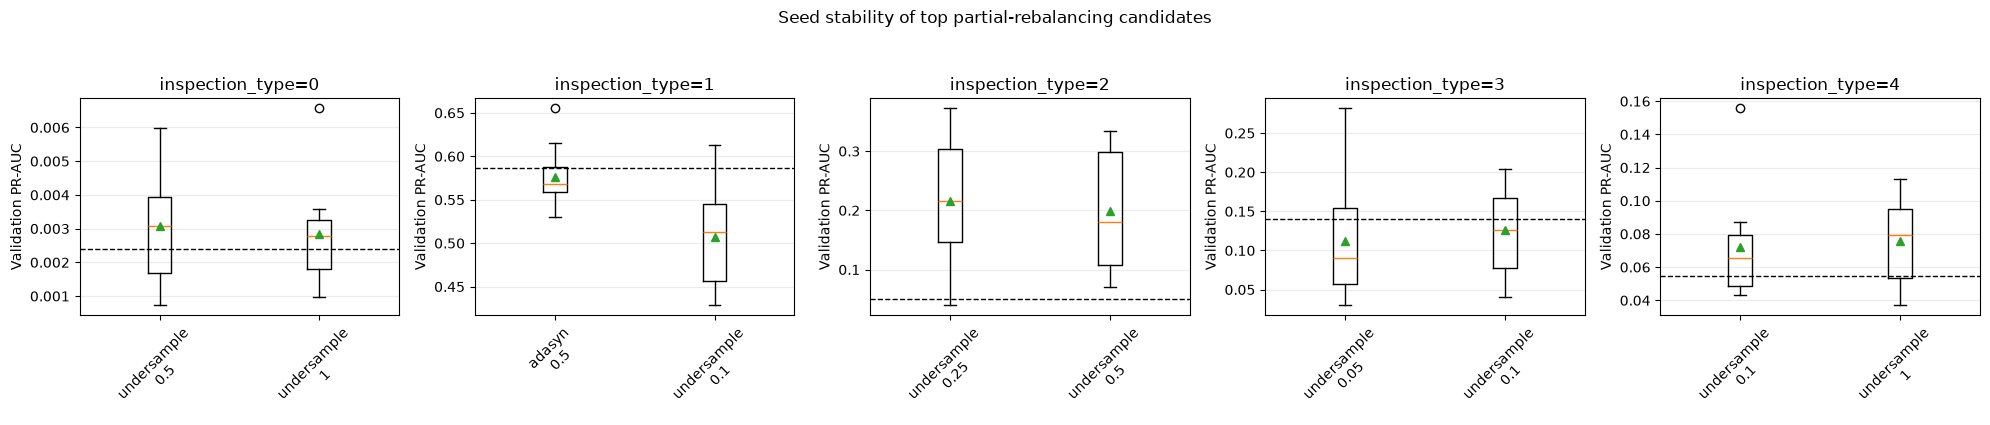

In [10]:
fig, axes = plt.subplots(1, len(inspection_types), figsize=(20, 4), sharey=False)

for ax, inspection_type in zip(axes, inspection_types):
    type_df = stability_df.loc[
        (stability_df["inspection_type"] == inspection_type)
        & (stability_df["status"] == "ok")
    ].copy()
    labels = []
    value_groups = []
    for (method, ratio), group in type_df.groupby(["method", "target_ratio"]):
        labels.append(f"{method}\n{ratio:g}")
        value_groups.append(group["validation_pr_auc"].to_numpy())
    if value_groups:
        ax.boxplot(value_groups, tick_labels=labels, showmeans=True)
    ax.axhline(
        baseline_validation.loc[inspection_type],
        color="black",
        linestyle="--",
        linewidth=1,
    )
    ax.set_title(f"inspection_type={inspection_type}")
    ax.set_ylabel("Validation PR-AUC")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Seed stability of top partial-rebalancing candidates", y=1.05)
plt.tight_layout()
plt.show()

## 8. 3단계: 설정 고정 후 최종 Test 평가

아래 셀을 실행하기 전에 `selected_configurations`가 Validation 결과만으로 생성됐는지 확인합니다. 이후 `FINAL_RESAMPLING_SEED=42`로 모델을 다시 학습하고 Test를 한 번 평가합니다.

두 가지 판정 방식을 함께 기록합니다.

- 고정 threshold 0.5: 006과 직접 비교
- Validation 최대 F1 threshold: 리샘플링으로 변한 확률 스케일을 고려한 보조 비교

Test 결과를 확인한 뒤 비율, 후보 수, seed 또는 선택 기준을 변경하면 별도 실험으로 분리합니다.

In [11]:
assert set(selected_configurations["inspection_type"]) == set(inspection_types)
assert not selected_configurations["robust_score"].isna().any()

final_models = {"baseline": {}, "selected": {}}
final_probabilities = {
    "baseline_validation": pd.Series(np.nan, index=clean_df.index, dtype="float64"),
    "baseline_test": pd.Series(np.nan, index=clean_df.index, dtype="float64"),
    "selected_validation": pd.Series(np.nan, index=clean_df.index, dtype="float64"),
    "selected_test": pd.Series(np.nan, index=clean_df.index, dtype="float64"),
}
selected_thresholds = {"baseline": {}, "selected": {}}
final_type_rows = []

for inspection_type in inspection_types:
    feature_columns = feature_columns_by_type[inspection_type]
    train_df = type_split_dfs[inspection_type]["train"]
    valid_df = type_split_dfs[inspection_type]["validation"]
    test_df = type_split_dfs[inspection_type]["test"]

    X_train = train_df[feature_columns]
    y_train = train_df[TARGET].astype("int8")
    X_valid = valid_df[feature_columns]
    y_valid = valid_df[TARGET].astype("int8")
    X_test = test_df[feature_columns]
    y_test = test_df[TARGET].astype("int8")

    selected_row = selected_configurations.loc[
        selected_configurations["inspection_type"] == inspection_type
    ].iloc[0]

    for variant, method, target_ratio in [
        ("baseline", "baseline", np.nan),
        ("selected", selected_row["method"], selected_row["target_ratio"]),
    ]:
        X_fit, y_fit = resample_training_data(
            X_train,
            y_train,
            method,
            target_ratio,
            FINAL_RESAMPLING_SEED,
        )
        model = build_model()
        model.fit(X_fit, y_fit, verbose=False)
        valid_probabilities = model.predict_proba(X_valid)[:, 1]
        test_probabilities = model.predict_proba(X_test)[:, 1]
        validation_threshold = select_f1_threshold(y_valid, valid_probabilities)

        final_models[variant][inspection_type] = model
        selected_thresholds[variant][inspection_type] = validation_threshold
        final_probabilities[f"{variant}_validation"].loc[valid_df.index] = valid_probabilities
        final_probabilities[f"{variant}_test"].loc[test_df.index] = test_probabilities

        for threshold_name, threshold in [
            ("fixed_0.5", DECISION_THRESHOLD),
            ("validation_f1", validation_threshold),
        ]:
            metrics = evaluate_probabilities(y_test, test_probabilities, threshold)
            final_type_rows.append(
                {
                    "inspection_type": inspection_type,
                    "variant": variant,
                    "method": method,
                    "target_ratio": target_ratio,
                    "threshold_policy": threshold_name,
                    **metrics,
                }
            )

final_type_results = pd.DataFrame(final_type_rows)
final_type_results

,inspection_type,variant,method,target_ratio,threshold_policy,threshold,tn,fp,fn,tp,accuracy,precision,recall,specificity,f1,roc_auc,pr_auc
0,0,baseline,baseline,NaN,fixed_0.5,0.500000,16651,0,132,1,0.992135,1.000000,0.007519,1.000000,0.014925,0.758519,0.068391
1,0,baseline,baseline,NaN,validation_f1,0.005011,16511,140,114,19,0.984867,0.119497,0.142857,0.991592,0.130137,0.758519,0.068391
2,0,selected,baseline,NaN,fixed_0.5,0.500000,16651,0,132,1,0.992135,1.000000,0.007519,1.000000,0.014925,0.758519,0.068391
3,0,selected,baseline,NaN,validation_f1,0.005011,16511,140,114,19,0.984867,0.119497,0.142857,0.991592,0.130137,0.758519,0.068391
4,1,baseline,baseline,NaN,fixed_0.5,0.500000,9720,608,427,357,0.906857,0.369948,0.455357,0.941131,0.408233,0.865324,0.391866
5,1,baseline,baseline,NaN,validation_f1,0.683535,10016,312,506,278,0.926386,0.471186,0.354592,0.969791,0.404658,0.865324,0.391866
6,1,selected,baseline,NaN,fixed_0.5,0.500000,9720,608,427,357,0.906857,0.369948,0.455357,0.941131,0.408233,0.865324,0.391866
7,1,selected,baseline,NaN,validation_f1,0.683535,10016,312,506,278,0.926386,0.471186,0.354592,0.969791,0.404658,0.865324,0.391866
8,2,baseline,baseline,NaN,fixed_0.5,0.500000,18220,230,460,243,0.963974,0.513742,0.345661,0.987534,0.413265,0.887697,0.356827
9,2,baseline,baseline,NaN,validation_f1,0.738900,18339,111,585,118,0.963661,0.515284,0.167852,0.993984,0.253219,0.887697,0.356827


In [12]:
def evaluate_pooled_variant(variant, threshold_policy):
    test_df = clean_df.loc[split_masks["test"]]
    probabilities = final_probabilities[f"{variant}_test"].loc[test_df.index]
    assert probabilities.notna().all()

    if threshold_policy == "fixed_0.5":
        thresholds = pd.Series(
            DECISION_THRESHOLD,
            index=test_df.index,
            dtype="float64",
        )
    elif threshold_policy == "validation_f1":
        thresholds = test_df[TYPE_COLUMN].map(selected_thresholds[variant]).astype("float64")
    else:
        raise ValueError(threshold_policy)

    predictions = (probabilities >= thresholds).astype("int8")
    y_true = test_df[TARGET].astype("int8")
    tn, fp, fn, tp = confusion_matrix(y_true, predictions, labels=[0, 1]).ravel()
    return {
        "variant": variant,
        "threshold_policy": threshold_policy,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "accuracy": accuracy_score(y_true, predictions),
        "precision": precision_score(y_true, predictions, zero_division=0),
        "recall": recall_score(y_true, predictions, zero_division=0),
        "specificity": tn / (tn + fp),
        "f1": f1_score(y_true, predictions, zero_division=0),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "pr_auc": average_precision_score(y_true, probabilities),
    }


pooled_results = pd.DataFrame(
    [
        evaluate_pooled_variant(variant, threshold_policy)
        for variant in ["baseline", "selected"]
        for threshold_policy in ["fixed_0.5", "validation_f1"]
    ]
).set_index(["variant", "threshold_policy"])

pooled_results

tn    fp    fn   tp  accuracy  precision  \
variant  threshold_policy                                                
baseline fixed_0.5         75192   955  1538  711  0.968200   0.426771   
         validation_f1     74860  1287  1802  447  0.960597   0.257785   
selected fixed_0.5         74758  1389  1360  889  0.964934   0.390255   
         validation_f1     74930  1217  1666  583  0.963225   0.323889   

                             recall  specificity        f1   roc_auc    pr_auc  
variant  threshold_policy                                                       
baseline fixed_0.5         0.316141     0.987458  0.363218  0.873366  0.315411  
         validation_f1     0.198755     0.983098  0.224454  0.873366  0.315411  
selected fixed_0.5         0.395287     0.981759  0.392755  0.870664  0.383311  
         validation_f1     0.259226     0.984018  0.287972  0.870664  0.383311

In [13]:
comparison_rows = []

for threshold_policy in ["fixed_0.5", "validation_f1"]:
    baseline_row = pooled_results.loc[("baseline", threshold_policy)]
    selected_row = pooled_results.loc[("selected", threshold_policy)]
    comparison_rows.append(
        {
            "threshold_policy": threshold_policy,
            "baseline_pr_auc": baseline_row["pr_auc"],
            "selected_pr_auc": selected_row["pr_auc"],
            "delta_pr_auc": selected_row["pr_auc"] - baseline_row["pr_auc"],
            "baseline_f1": baseline_row["f1"],
            "selected_f1": selected_row["f1"],
            "delta_f1": selected_row["f1"] - baseline_row["f1"],
            "baseline_recall": baseline_row["recall"],
            "selected_recall": selected_row["recall"],
            "delta_recall": selected_row["recall"] - baseline_row["recall"],
            "delta_tn": int(selected_row["tn"] - baseline_row["tn"]),
            "delta_fn": int(selected_row["fn"] - baseline_row["fn"]),
        }
    )

pooled_comparison = pd.DataFrame(comparison_rows).set_index("threshold_policy")
pooled_comparison

,baseline_pr_auc,selected_pr_auc,delta_pr_auc,baseline_f1,selected_f1,delta_f1,baseline_recall,selected_recall,delta_recall,delta_tn,delta_fn
threshold_policy,,,,,,,,,,,
fixed_0.5,0.315411,0.383311,0.0679,0.363218,0.392755,0.029536,0.316141,0.395287,0.079146,-434,-178
validation_f1,0.315411,0.383311,0.0679,0.224454,0.287972,0.063518,0.198755,0.259226,0.060471,70,-136


## 9. 결론 및 다음 단계

### 실행 검증

- 코드 셀 13개를 위에서 아래로 전체 실행했습니다.
- 실행 오류는 0건입니다.
- 중복 제거 후 391,992행을 사용했습니다.
- Train/Validation/Test는 235,222 / 78,374 / 78,396행입니다.
- Screening 80회, seed 안정성 검증 100회와 최종 비교 학습을 완료했습니다.

### Validation 기반 최종 선택

| inspection_type | 최종 설정 | Validation PR-AUC 평균 | 표준편차 | robust score | Baseline 승리 seed 비율 |
|---:|---|---:|---:|---:|---:|
| 0 | baseline | 0.002405 | 0 | 0.002405 | 해당 없음 |
| 1 | baseline | 0.586063 | 0 | 0.586063 | 해당 없음 |
| 2 | undersample, ratio 0.25 | 0.215149 | 0.110551 | 0.104598 | 90% |
| 3 | baseline | 0.140335 | 0 | 0.140335 | 해당 없음 |
| 4 | baseline | 0.054825 | 0 | 0.054825 | 해당 없음 |

Type 2만 약 1:4 부분 undersampling을 선택했고 나머지 유형은 리샘플링의 변동성 패널티를 고려했을 때 baseline이 더 안전했습니다.

### Type 2 Test 결과

| 조건 | 모델 | Threshold | PR-AUC | Precision | Recall | F1 | TN | FP | FN | TP |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 고정 0.5 | baseline | 0.500000 | 0.356827 | 0.513742 | 0.345661 | 0.413265 | 18,220 | 230 | 460 | 243 |
| 고정 0.5 | undersample 0.25 | 0.500000 | 0.561603 | 0.388018 | 0.598862 | 0.470917 | 17,786 | 664 | 282 | 421 |
| Validation F1 | baseline | 0.738900 | 0.356827 | 0.515284 | 0.167852 | 0.253219 | 18,339 | 111 | 585 | 118 |
| Validation F1 | undersample 0.25 | 0.970494 | 0.561603 | 0.861017 | 0.361309 | 0.509018 | 18,409 | 41 | 449 | 254 |

고정 threshold 0.5에서는 Type 2 PR-AUC가 0.356827에서 0.561603으로 상승했고 Recall은 34.57%에서 59.89%로 상승했습니다. 그 대가로 TN은 434건 감소했지만 FN은 178건 감소했습니다.

Validation F1 threshold에서는 선택 모델이 baseline보다 TN 70건과 TP 136건을 더 확보해 TN·FN 관점에서 동시에 개선됐습니다.

### Pooled Test 결과

| Threshold 정책 | 모델 | PR-AUC | Precision | Recall | F1 | TN | FP | FN | TP |
|---|---|---:|---:|---:|---:|---:|---:|---:|---:|
| 고정 0.5 | baseline | 0.315411 | 0.426771 | 0.316141 | 0.363218 | 75,192 | 955 | 1,538 | 711 |
| 고정 0.5 | selected | 0.383311 | 0.390255 | 0.395287 | 0.392755 | 74,758 | 1,389 | 1,360 | 889 |
| Validation F1 | baseline | 0.315411 | 0.257785 | 0.198755 | 0.224454 | 74,860 | 1,287 | 1,802 | 447 |
| Validation F1 | selected | 0.383311 | 0.323889 | 0.259226 | 0.287972 | 74,930 | 1,217 | 1,666 | 583 |

Pooled PR-AUC는 0.315411에서 0.383311로 상승했지만, 서로 다른 type 모델의 확률 스케일이 직접 비교 가능하다고 보장되지 않으므로 보조 지표로만 해석합니다. 주 결론은 Type 2 내부 PR-AUC와 confusion matrix 개선입니다.

### 결론

- 1:1 완전 균형을 모든 유형에 적용하는 전략은 채택하지 않습니다.
- 부분 리샘플링 가설은 **Type 2에 한해 지지**됩니다.
- Type 0·1·3·4는 seed 안정성까지 고려하면 baseline 유지가 최선입니다.
- Type 2의 1:4 undersampling은 Test PR-AUC와 F1을 개선했지만 Validation PR-AUC 표준편차가 0.110551로 커서 시간 구간이나 표본 추출에 대한 불확실성이 남습니다.
- Validation 최대 F1 threshold는 Type 3에서 0.999992처럼 극단적인 값을 선택해 Test Recall이 0.995%로 떨어졌습니다. sparse positive와 drift가 있는 상황에서 단일 Validation F1 threshold는 별도 안정성 검증 없이 운영 기준으로 사용하면 안 됩니다.

Test를 이미 확인했으므로 ratio, 후보 수, seed 또는 선택 기준을 이 실험 안에서 다시 변경하지 않습니다. 후속 검증은 새로운 실험 ID에서 walk-forward 시간 구간을 사용해 Type 2의 1:4 undersampling 재현성을 확인해야 합니다.

이번 노트북은 비교 실험이므로 모델 파일을 저장하지 않습니다.